### Connexion a Google Drive

In [2]:
# Montage de Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports des bibliotheques

In [3]:
# Imports des bibliotheques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Configuration des graphiques
plt.style.use('ggplot')
sns.set_palette("husl")

## Chargement des donnees

In [5]:
# Chargement des donnees
# A modifier selon l'emplacement de votre fichier
FILE_PATH = '/content/drive/MyDrive/apprentissage_supervisé_aihub/SupervisedLearning/Classification/Doc 1/Car_Data.csv'
df = pd.read_csv(FILE_PATH)

print("Donnees chargees avec succes")
print(f"Dimensions : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")

Donnees chargees avec succes
Dimensions : (5507, 6)
Colonnes : ['Marque', 'Année', 'Boite_Vitesse', 'Adresse', 'Prix', 'Venant_Occasion']


## Apercu des donnees

In [6]:
# Apercu des donnees
display(df.head())

,Marque,Année,Boite_Vitesse,Adresse,Prix,Venant_Occasion
0,Mitsubishi,2017,Automatique,"Liberte 6,Dakar",9750000,Venant
1,Ford,2009,Manuelle,"Yoff,Dakar",2500000,D'occasion
2,BMW,2015,Automatique,"Cité Damel,Dakar",15500000,D'occasion
3,Ford,2013,Automatique,"Almadies,Dakar",3800000,D'occasion
4,GMC,2014,Automatique,"Hlm,Dakar",7500000,Venant


## Statistiques descriptives

In [7]:
# Statistiques descriptives
print("Statistiques descriptives (variables numeriques) :")
display(df.describe())

print("\nInformations sur les donnees :")
df.info()

Statistiques descriptives (variables numeriques) :


,Année,Prix
count,5507.000000,5.507000e+03
mean,2014.508444,1.110512e+07
std,3.089839,1.619639e+07
min,1990.000000,1.000000e+00
25%,2013.000000,4.600000e+06
50%,2015.000000,7.800000e+06
75%,2016.000000,1.250000e+07
max,2024.000000,7.794141e+08



Informations sur les donnees :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5507 entries, 0 to 5506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Marque           5507 non-null   object
 1   Année            5507 non-null   int64 
 2   Boite_Vitesse    5507 non-null   object
 3   Adresse          5507 non-null   object
 4   Prix             5507 non-null   int64 
 5   Venant_Occasion  5507 non-null   object
dtypes: int64(2), object(4)
memory usage: 258.3+ KB


## Distribution de la variable cible

Distribution de la variable cible :
Venant_Occasion
Venant        2855
D'occasion    2652
Name: count, dtype: int64


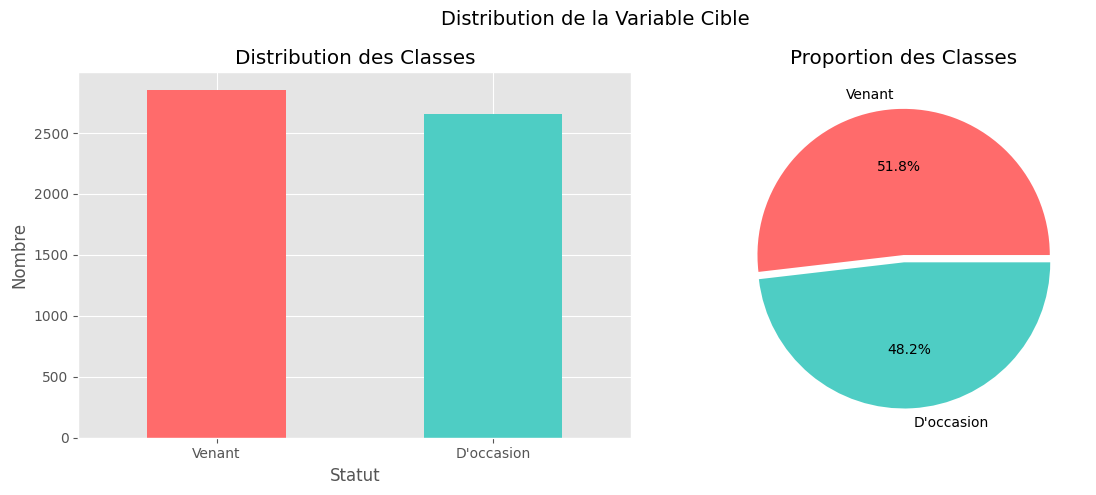

In [8]:
# Distribution de la variable cible
etat_counts = df['Venant_Occasion'].value_counts()
print("Distribution de la variable cible :")
print(etat_counts)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
etat_counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Distribution des Classes')
axes[0].set_xlabel('Statut')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
etat_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                 colors=['#FF6B6B', '#4ECDC4'], explode=[0, 0.05])
axes[1].set_title('Proportion des Classes')
axes[1].set_ylabel('')

plt.suptitle('Distribution de la Variable Cible', fontsize=14)
plt.tight_layout()
plt.show()

## Analyse des variables numeriques

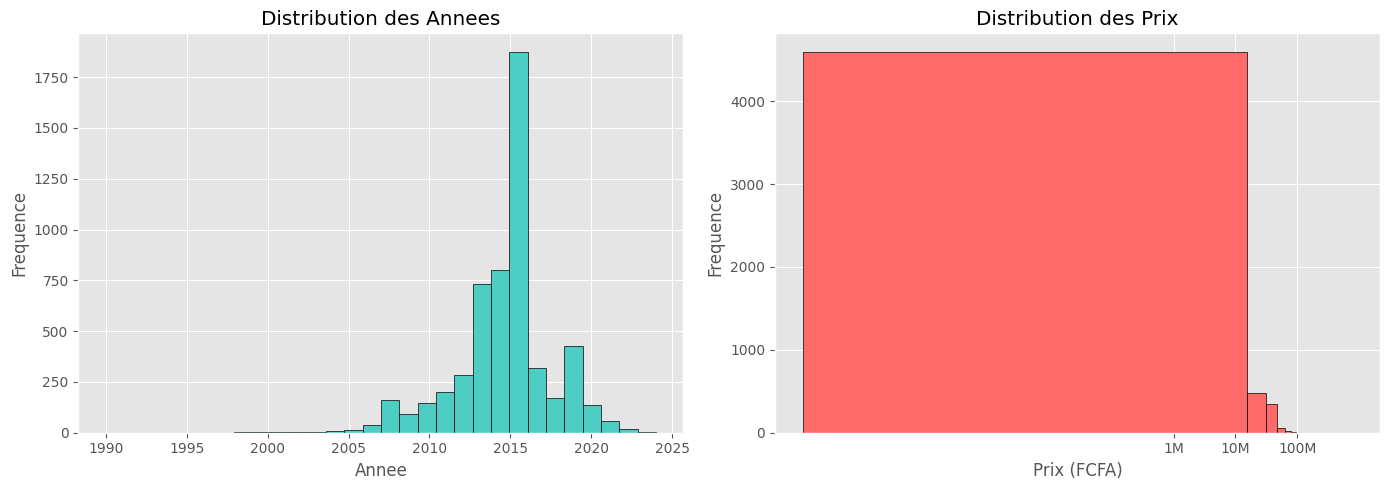

In [9]:
# Analyse des variables numeriques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de l'annee
df['Année'].hist(bins=30, ax=axes[0], color='#4ECDC4', edgecolor='black')
axes[0].set_title('Distribution des Annees')
axes[0].set_xlabel('Annee')
axes[0].set_ylabel('Frequence')

# Distribution du prix (avec echelle logarithmique)
df['Prix'].hist(bins=50, ax=axes[1], color='#FF6B6B', edgecolor='black')
axes[1].set_title('Distribution des Prix')
axes[1].set_xlabel('Prix (FCFA)')
axes[1].set_ylabel('Frequence')
axes[1].set_xscale('log')
axes[1].set_xticks([1e6, 1e7, 1e8])
axes[1].set_xticklabels(['1M', '10M', '100M'])

plt.tight_layout()
plt.show()

 Analyse des variables categorielles

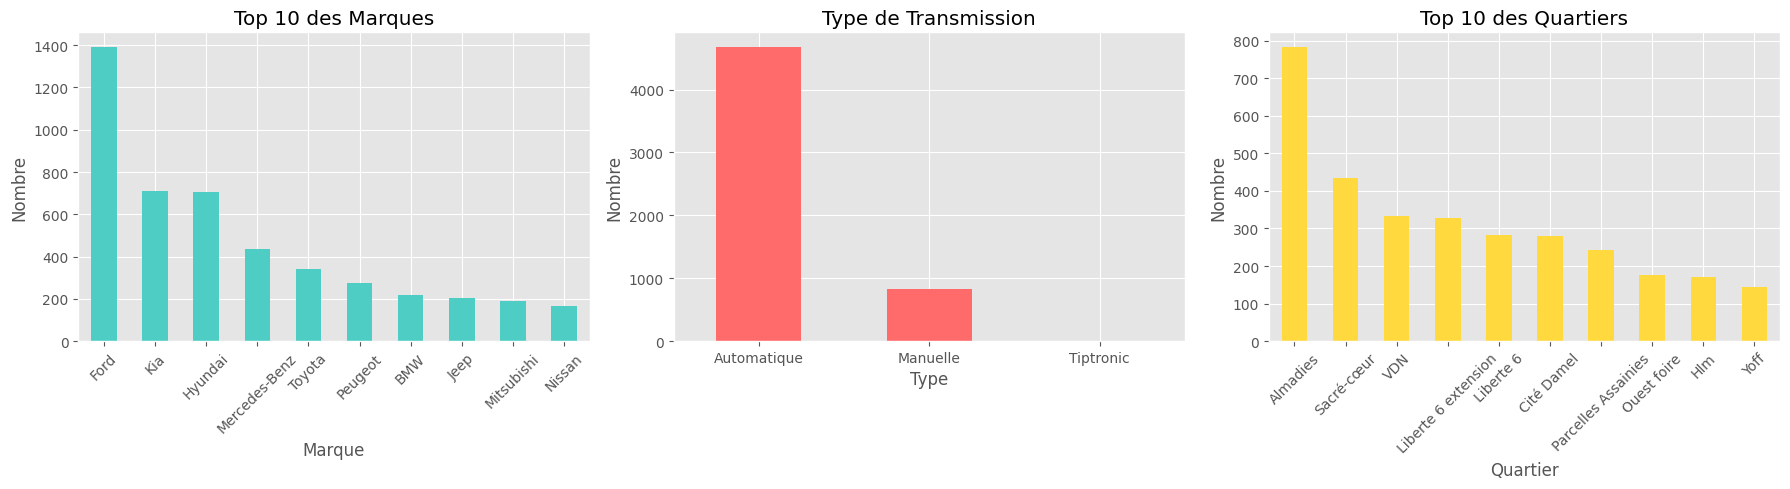

In [10]:
# Analyse des variables categorielles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top 10 des marques
df['Marque'].value_counts().head(10).plot(kind='bar', ax=axes[0], color='#4ECDC4')
axes[0].set_title('Top 10 des Marques')
axes[0].set_xlabel('Marque')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=45)

# Distribution des transmissions
df['Boite_Vitesse'].value_counts().plot(kind='bar', ax=axes[1], color='#FF6B6B')
axes[1].set_title('Type de Transmission')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Nombre')
axes[1].tick_params(axis='x', rotation=0)

# Top 10 des quartiers
df['Adresse'].str.split(',').str[0].value_counts().head(10).plot(kind='bar', ax=axes[2], color='#FFD93D')
axes[2].set_title('Top 10 des Quartiers')
axes[2].set_xlabel('Quartier')
axes[2].set_ylabel('Nombre')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Nettoyage des donnees

In [11]:
# Nettoyage des donnees

# Extraction du quartier
df[['Quartier', 'Region']] = df['Adresse'].str.split(',', n=1, expand=True)
df = df.drop(['Adresse', 'Region'], axis=1)

# Nettoyage des textes
df['Quartier'] = df['Quartier'].str.strip().str.title()
df['Marque'] = df['Marque'].str.strip().str.title()

# Renommage des colonnes
df = df.rename(columns={
    'Boite_Vitesse': 'Transmission',
    'Venant_Occasion': 'Etat'
})

print("Donnees apres nettoyage :")
display(df.head())
print(f"Nombre de quartiers uniques : {df['Quartier'].nunique()}")
print(f"Nombre de marques uniques : {df['Marque'].nunique()}")

Donnees apres nettoyage :


,Marque,Année,Transmission,Prix,Etat,Quartier
0,Mitsubishi,2017,Automatique,9750000,Venant,Liberte 6
1,Ford,2009,Manuelle,2500000,D'occasion,Yoff
2,Bmw,2015,Automatique,15500000,D'occasion,Cité Damel
3,Ford,2013,Automatique,3800000,D'occasion,Almadies
4,Gmc,2014,Automatique,7500000,Venant,Hlm


Nombre de quartiers uniques : 85
Nombre de marques uniques : 46


## Encodage des variables

In [12]:
# Encodage des variables categorielles
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}

for col in ['Marque', 'Transmission', 'Quartier']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Encodage de la variable cible
df_encoded['Etat'] = LabelEncoder().fit_transform(df_encoded['Etat'])

print("Donnees encodees :")
display(df_encoded.head())

Donnees encodees :


,Marque,Année,Transmission,Prix,Etat,Quartier
0,30,2017,0,9750000,1,48
1,13,2009,1,2500000,0,82
2,3,2015,0,15500000,0,15
3,13,2013,0,3800000,0,0
4,14,2014,0,7500000,1,38


## Mapping des encodages

In [13]:
# Affichage des mappings
mappings = {}
for col, le in label_encoders.items():
    mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("Mappings des encodages :")
for col, mapping in mappings.items():
    print(f"\n{col}:")
    for k, v in list(mapping.items())[:5]:
        print(f"  {k} -> {v}")

Mappings des encodages :

Marque:
  Acura -> 0
  Audi -> 1
  Autres -> 2
  Bmw -> 3
  Buick -> 4

Transmission:
  Automatique -> 0
  Manuelle -> 1
  Tiptronic -> 2

Quartier:
  Almadies -> 0
  Almadies 2 -> 1
  Amitié -> 2
  Avenue Bourguiba -> 3
  Bambilor -> 4


## Preparation des donnees pour le modele

In [14]:
# Preparation des donnees
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Separation X / y
X = df_encoded.drop('Etat', axis=1)
y = df_encoded['Etat']

# Normalisation
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Division en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille train : {X_train.shape[0]} observations")
print(f"Taille test : {X_test.shape[0]} observations")
print(f"Distribution train : {np.bincount(y_train)}")
print(f"Distribution test : {np.bincount(y_test)}")

Taille train : 4405 observations
Taille test : 1102 observations
Distribution train : [2121 2284]
Distribution test : [531 571]


## Recherche du meilleur K

In [15]:
# Recherche du meilleur K
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

print("Recherche du meilleur K...")

k_values = list(range(1, 31))
grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': k_values},
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_k = grid.best_params_['n_neighbors']
best_score = grid.best_score_

print(f"Meilleur K : {best_k}")
print(f"Meilleur score (validation croisee) : {best_score:.4f}")

Recherche du meilleur K...
Meilleur K : 5
Meilleur score (validation croisee) : 0.7812


## Visualisation de la selection de K

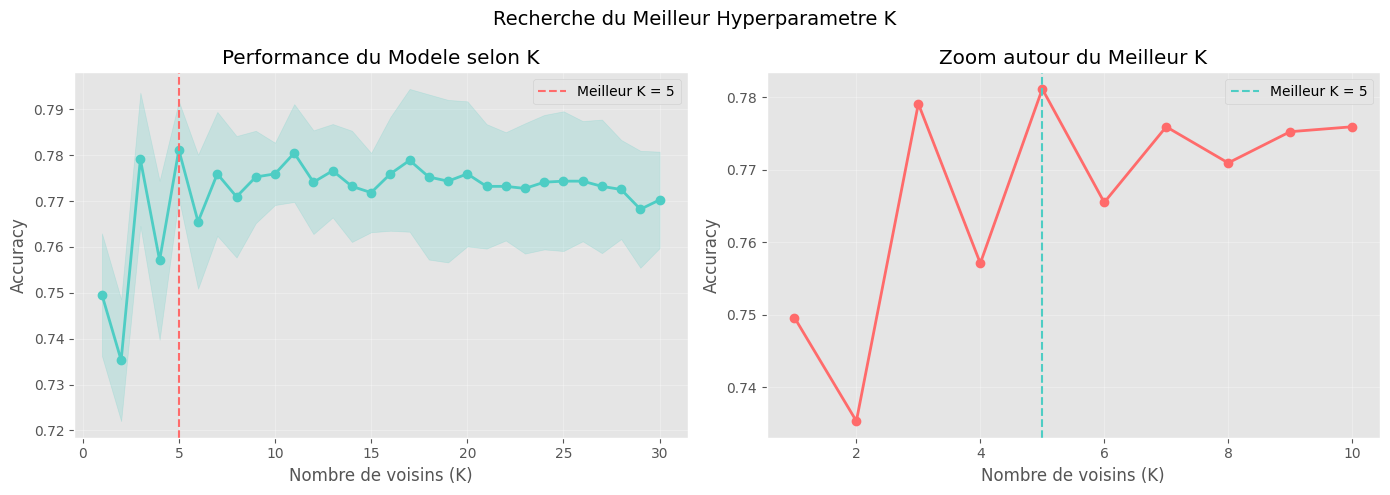

In [16]:
# Visualisation des performances selon K
cv_results = pd.DataFrame(grid.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe d'accuracy
axes[0].plot(k_values, cv_results['mean_test_score'], 'o-', color='#4ECDC4', linewidth=2)
axes[0].fill_between(k_values,
                     cv_results['mean_test_score'] - cv_results['std_test_score'],
                     cv_results['mean_test_score'] + cv_results['std_test_score'],
                     alpha=0.2, color='#4ECDC4')
axes[0].axvline(best_k, color='#FF6B6B', linestyle='--', label=f'Meilleur K = {best_k}')
axes[0].set_title('Performance du Modele selon K')
axes[0].set_xlabel('Nombre de voisins (K)')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoom autour du meilleur K
best_range = range(max(1, best_k-5), min(30, best_k+6))
mask = cv_results['param_n_neighbors'].isin(best_range)
axes[1].plot(cv_results[mask]['param_n_neighbors'],
             cv_results[mask]['mean_test_score'],
             'o-', color='#FF6B6B', linewidth=2)
axes[1].axvline(best_k, color='#4ECDC4', linestyle='--', label=f'Meilleur K = {best_k}')
axes[1].set_title('Zoom autour du Meilleur K')
axes[1].set_xlabel('Nombre de voisins (K)')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Recherche du Meilleur Hyperparametre K', fontsize=14)
plt.tight_layout()
plt.show()

## Entrainement du modele final

In [17]:
# Entrainement du modele final
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metriques
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Resultats du modele :")
print(f"  - Accuracy : {accuracy:.4f}")
print(f"  - ROC-AUC  : {roc_auc:.4f}")
print(f"\nRapport de classification :")
print(classification_report(y_test, y_pred,
                           target_names=['D\'occasion', 'Venant']))

Resultats du modele :
  - Accuracy : 0.7650
  - ROC-AUC  : 0.8321

Rapport de classification :
              precision    recall  f1-score   support

  D'occasion       0.78      0.71      0.75       531
      Venant       0.75      0.81      0.78       571

    accuracy                           0.76      1102
   macro avg       0.77      0.76      0.76      1102
weighted avg       0.77      0.76      0.76      1102



## Matrice de confusion

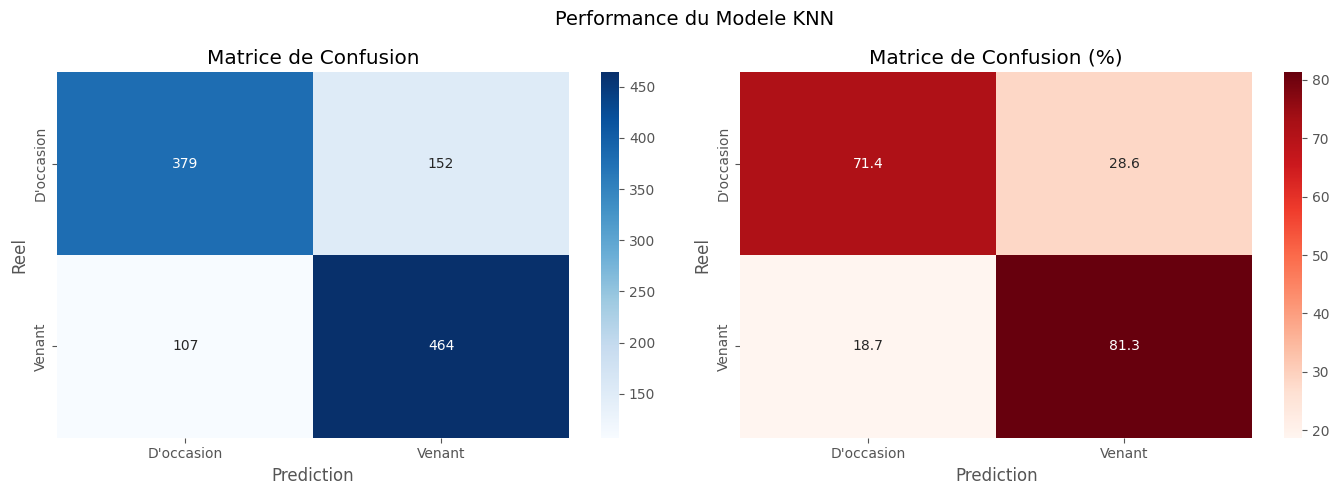

In [18]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valeurs absolues
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['D\'occasion', 'Venant'],
            yticklabels=['D\'occasion', 'Venant'])
axes[0].set_title('Matrice de Confusion')
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Reel')

# Pourcentages
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Reds', ax=axes[1],
            xticklabels=['D\'occasion', 'Venant'],
            yticklabels=['D\'occasion', 'Venant'])
axes[1].set_title('Matrice de Confusion (%)')
axes[1].set_xlabel('Prediction')
axes[1].set_ylabel('Reel')

plt.suptitle('Performance du Modele KNN', fontsize=14)
plt.tight_layout()
plt.show()

## Importance des caracteristiques

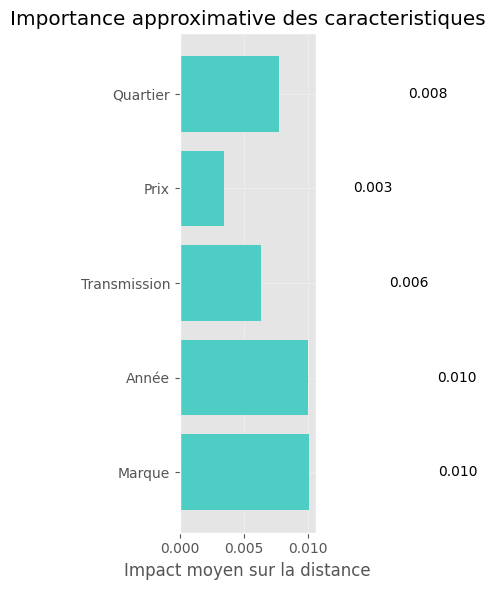

In [19]:
# Importance approximative des caracteristiques
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=best_k)
nn.fit(X_train)

# Distance moyenne pour chaque feature
distances, _ = nn.kneighbors(X_train)
feature_importance = []

for i in range(X_train.shape[1]):
    X_permuted = X_train.copy()
    np.random.shuffle(X_permuted[:, i])
    nn_perm = NearestNeighbors(n_neighbors=best_k)
    nn_perm.fit(X_permuted)
    dist_perm, _ = nn_perm.kneighbors(X_train)
    importance = np.mean(dist_perm - distances)
    feature_importance.append(importance)

feature_names = X.columns

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feature_names, feature_importance, color='#4ECDC4')
ax.set_title('Importance approximative des caracteristiques')
ax.set_xlabel('Impact moyen sur la distance')
ax.grid(True, alpha=0.3)

# Ajout des valeurs
for bar, val in zip(bars, feature_importance):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()

## Sauvegarde du modele

In [20]:
# Sauvegarde du modele
import joblib
import os

# Creation du dossier models
os.makedirs('models', exist_ok=True)

# Sauvegarde du modele
model_path = 'models/knn_model.pkl'
joblib.dump(model, model_path)
print(f"Modele sauvegarde : {model_path}")

# Sauvegarde du scaler
scaler_path = 'models/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler sauvegarde : {scaler_path}")

# Sauvegarde des mappings
mappings_path = 'models/mappings.pkl'
joblib.dump({
    'feature_names': X.columns.tolist(),
    'label_encoders': label_encoders,
    'target_mapping': {0: "D'occasion", 1: "Venant"},
    'best_k': best_k,
    'accuracy': accuracy,
    'roc_auc': roc_auc
}, mappings_path)
print(f"Mappings sauvegardes : {mappings_path}")

Modele sauvegarde : models/knn_model.pkl
Scaler sauvegarde : models/scaler.pkl
Mappings sauvegardes : models/mappings.pkl


## Fonction de prediction

In [21]:
# Fonction de prediction
def predict_car_status(features):
    """
    Fonction pour predire le statut d'une voiture

    Parameters:
    -----------
    features : dict
        Dictionnaire avec les caracteristiques :
        - Marque (str)
        - Annee (int)
        - Transmission (str)
        - Quartier (str)
        - Prix (int)

    Returns:
    --------
    str : "Venant" ou "D'occasion"
    float : probabilite associee
    """
    df_input = pd.DataFrame([features])

    # Encodage
    for col in ['Marque', 'Transmission', 'Quartier']:
        if col in df_input.columns:
            df_input[col] = label_encoders[col].transform(df_input[col])

    # Reorganisation des colonnes
    df_input = df_input[X.columns]

    # Normalisation
    df_input_scaled = scaler.transform(df_input)

    # Prediction
    pred = model.predict(df_input_scaled)[0]
    proba = model.predict_proba(df_input_scaled)[0][pred]

    result = "Venant" if pred == 1 else "D'occasion"
    return result, proba

## Test de la fonction

In [23]:
test_car = {
    'Marque': 'Toyota',
    'Année': 2020,
    'Transmission': 'Automatique',
    'Quartier': 'Mermoz',
    'Prix': 15000000
}

pred, proba = predict_car_status(test_car)

print("Test de prediction :")
print("-" * 40)
print(f"Voiture : Toyota 2020 (Automatique) a Mermoz")
print(f"Prix : 15 000 000 FCFA")
print("-" * 40)
print(f"Prediction : {pred}")
print(f"Probabilite : {proba:.2%}")

Test de prediction :
----------------------------------------
Voiture : Toyota 2020 (Automatique) a Mermoz
Prix : 15 000 000 FCFA
----------------------------------------
Prediction : Venant
Probabilite : 80.00%


## Resume du projet

In [24]:
# Resume du projet
print("="*50)
print("RESUME DU PROJET")
print("="*50)

print(f"""
Projet : Prediction du statut des voitures (Venant vs D'occasion)

Objectif : Classifier les voitures selon qu'elles sont importees neuves
           ou d'occasion a partir de leurs caracteristiques.

Modele utilise : K-Nearest Neighbors (KNN)

Performances :
  - Accuracy  : {accuracy:.2%}
  - ROC-AUC   : {roc_auc:.2%}
  - Meilleur K: {best_k}

Caracteristiques utilisees :
  {', '.join(X.columns.tolist())}

Nombre d'observations :
  - Total    : {len(df)}
  - Train    : {len(X_train)}
  - Test     : {len(X_test)}
""")

print("Fin du notebook.")

RESUME DU PROJET

Projet : Prediction du statut des voitures (Venant vs D'occasion)

Objectif : Classifier les voitures selon qu'elles sont importees neuves 
           ou d'occasion a partir de leurs caracteristiques.

Modele utilise : K-Nearest Neighbors (KNN)

Performances :
  - Accuracy  : 76.50%
  - ROC-AUC   : 83.21%
  - Meilleur K: 5

Caracteristiques utilisees :
  Marque, Année, Transmission, Prix, Quartier

Nombre d'observations :
  - Total    : 5507
  - Train    : 4405
  - Test     : 1102

Fin du notebook.
